In [1]:
import os

import pandas as pd
import numpy as np
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize


In [2]:
# Load files

df = pd.read_csv("../data/pooled_estimates/pooled_full_specification.csv")

SHAPEFILE_PATH = os.path.expanduser(
    "../data/raw/map/CTYUA_DEC_2023_UK_BFC.shp"
)
england_map = gpd.read_file(
    SHAPEFILE_PATH
)

rgn = gpd.read_file("../data/raw/map/OA21_WD22_LAD22_CTYUA22_RGN22_CTRY22_EW_LU_v2.shp", ignore_geometry=True)

In [3]:
# Identify top 5 and bottom 5 authorities
top5_care = (
    df.nlargest(5, "care_1000_est")
      [["area_code", "area_name", "population_65plus", "care_1000_est"]]
      .reset_index(drop=True)
)

print("\nTOP 5 — CARE NEED PER 1,000 AGED 50+")
print(top5_care.to_string(index=False))

top5_care = (
    df.nsmallest(5, "care_1000_est")
      [["area_code", "area_name", "population_65plus", "care_1000_est"]]
      .reset_index(drop=True)
)

print("\nTOP 5 — CARE NEED PER 1,000 AGED 50+")
print(top5_care.to_string(index=False))


TOP 5 — CARE NEED PER 1,000 AGED 50+
area_code            area_name  population_65plus  care_1000_est
E09000030        Tower Hamlets              17472     458.974823
E08000028             Sandwell              49705     448.911521
E08000003           Manchester              52167     443.002614
E08000011             Knowsley              26242     441.917276
E09000002 Barking and Dagenham              19030     440.413378

TOP 5 — CARE NEED PER 1,000 AGED 50+
area_code            area_name  population_65plus  care_1000_est
E09000001       City of London               1206     297.301556
E09000027 Richmond upon Thames              31447     328.693011
E06000017              Rutland              10384     331.236196
E06000041            Wokingham              30549     332.185401
E06000037       West Berkshire              31512     335.870940


In [4]:
# Identify regional distribution

j = rgn[["OA21CD", "UTLA22CD", "UTLA22NM", "RGN22CD", "RGN22NM"]]

multi = j.groupby("UTLA22CD")["RGN22NM"].nunique()

utla_region = (
    j[["UTLA22CD", "UTLA22NM", "RGN22CD", "RGN22NM"]]
    .dropna(subset=["UTLA22CD", "RGN22CD"])
    .drop_duplicates()
    .rename(columns={
        "UTLA22CD": "area_code",
        "UTLA22NM": "ons_area_name",
        "RGN22CD": "region_code",
        "RGN22NM": "region",
    })
)

utla_region = utla_region[
    utla_region["area_code"].str.startswith("E")
].reset_index(drop=True)


df = df.merge(
    utla_region[["area_code", "region_code", "region"]],
    on="area_code", how="left")

In [5]:
df["care_count_est"] = df["care_1000_est"] / 1000 * df["population_65plus"]

regional = (
    df
    .groupby("region", as_index=False)
    .agg(
        n_authorities=("area_code", "nunique"),
        population_65plus=("population_65plus", "sum"),
        care_count_est=("care_count_est", "sum"),
    )
)

regional["care_1000_est"] = (
    regional["care_count_est"] / regional["population_65plus"] * 1000
)

print(regional.sort_values("care_1000_est", ascending=False).to_string(index=False))

                  region  n_authorities  population_65plus  care_count_est  care_1000_est
              North East             12             540562   220029.183843     407.037831
Yorkshire and The Humber             14             887161   351589.688182     396.308774
              North West             22            1264788   497567.261995     393.399733
           West Midlands             14            1117228   437981.331736     392.025022
           East Midlands             10             951780   363060.960847     381.454707
                  London             33            1043420   397092.976299     380.568684
         East of England             11            1243126   456959.520508     367.589062
              South West             14            1131732   412089.621814     364.122974
              South East             19            1804256   645996.182639     358.040202


153 authorities on the map, 153 with an estimate


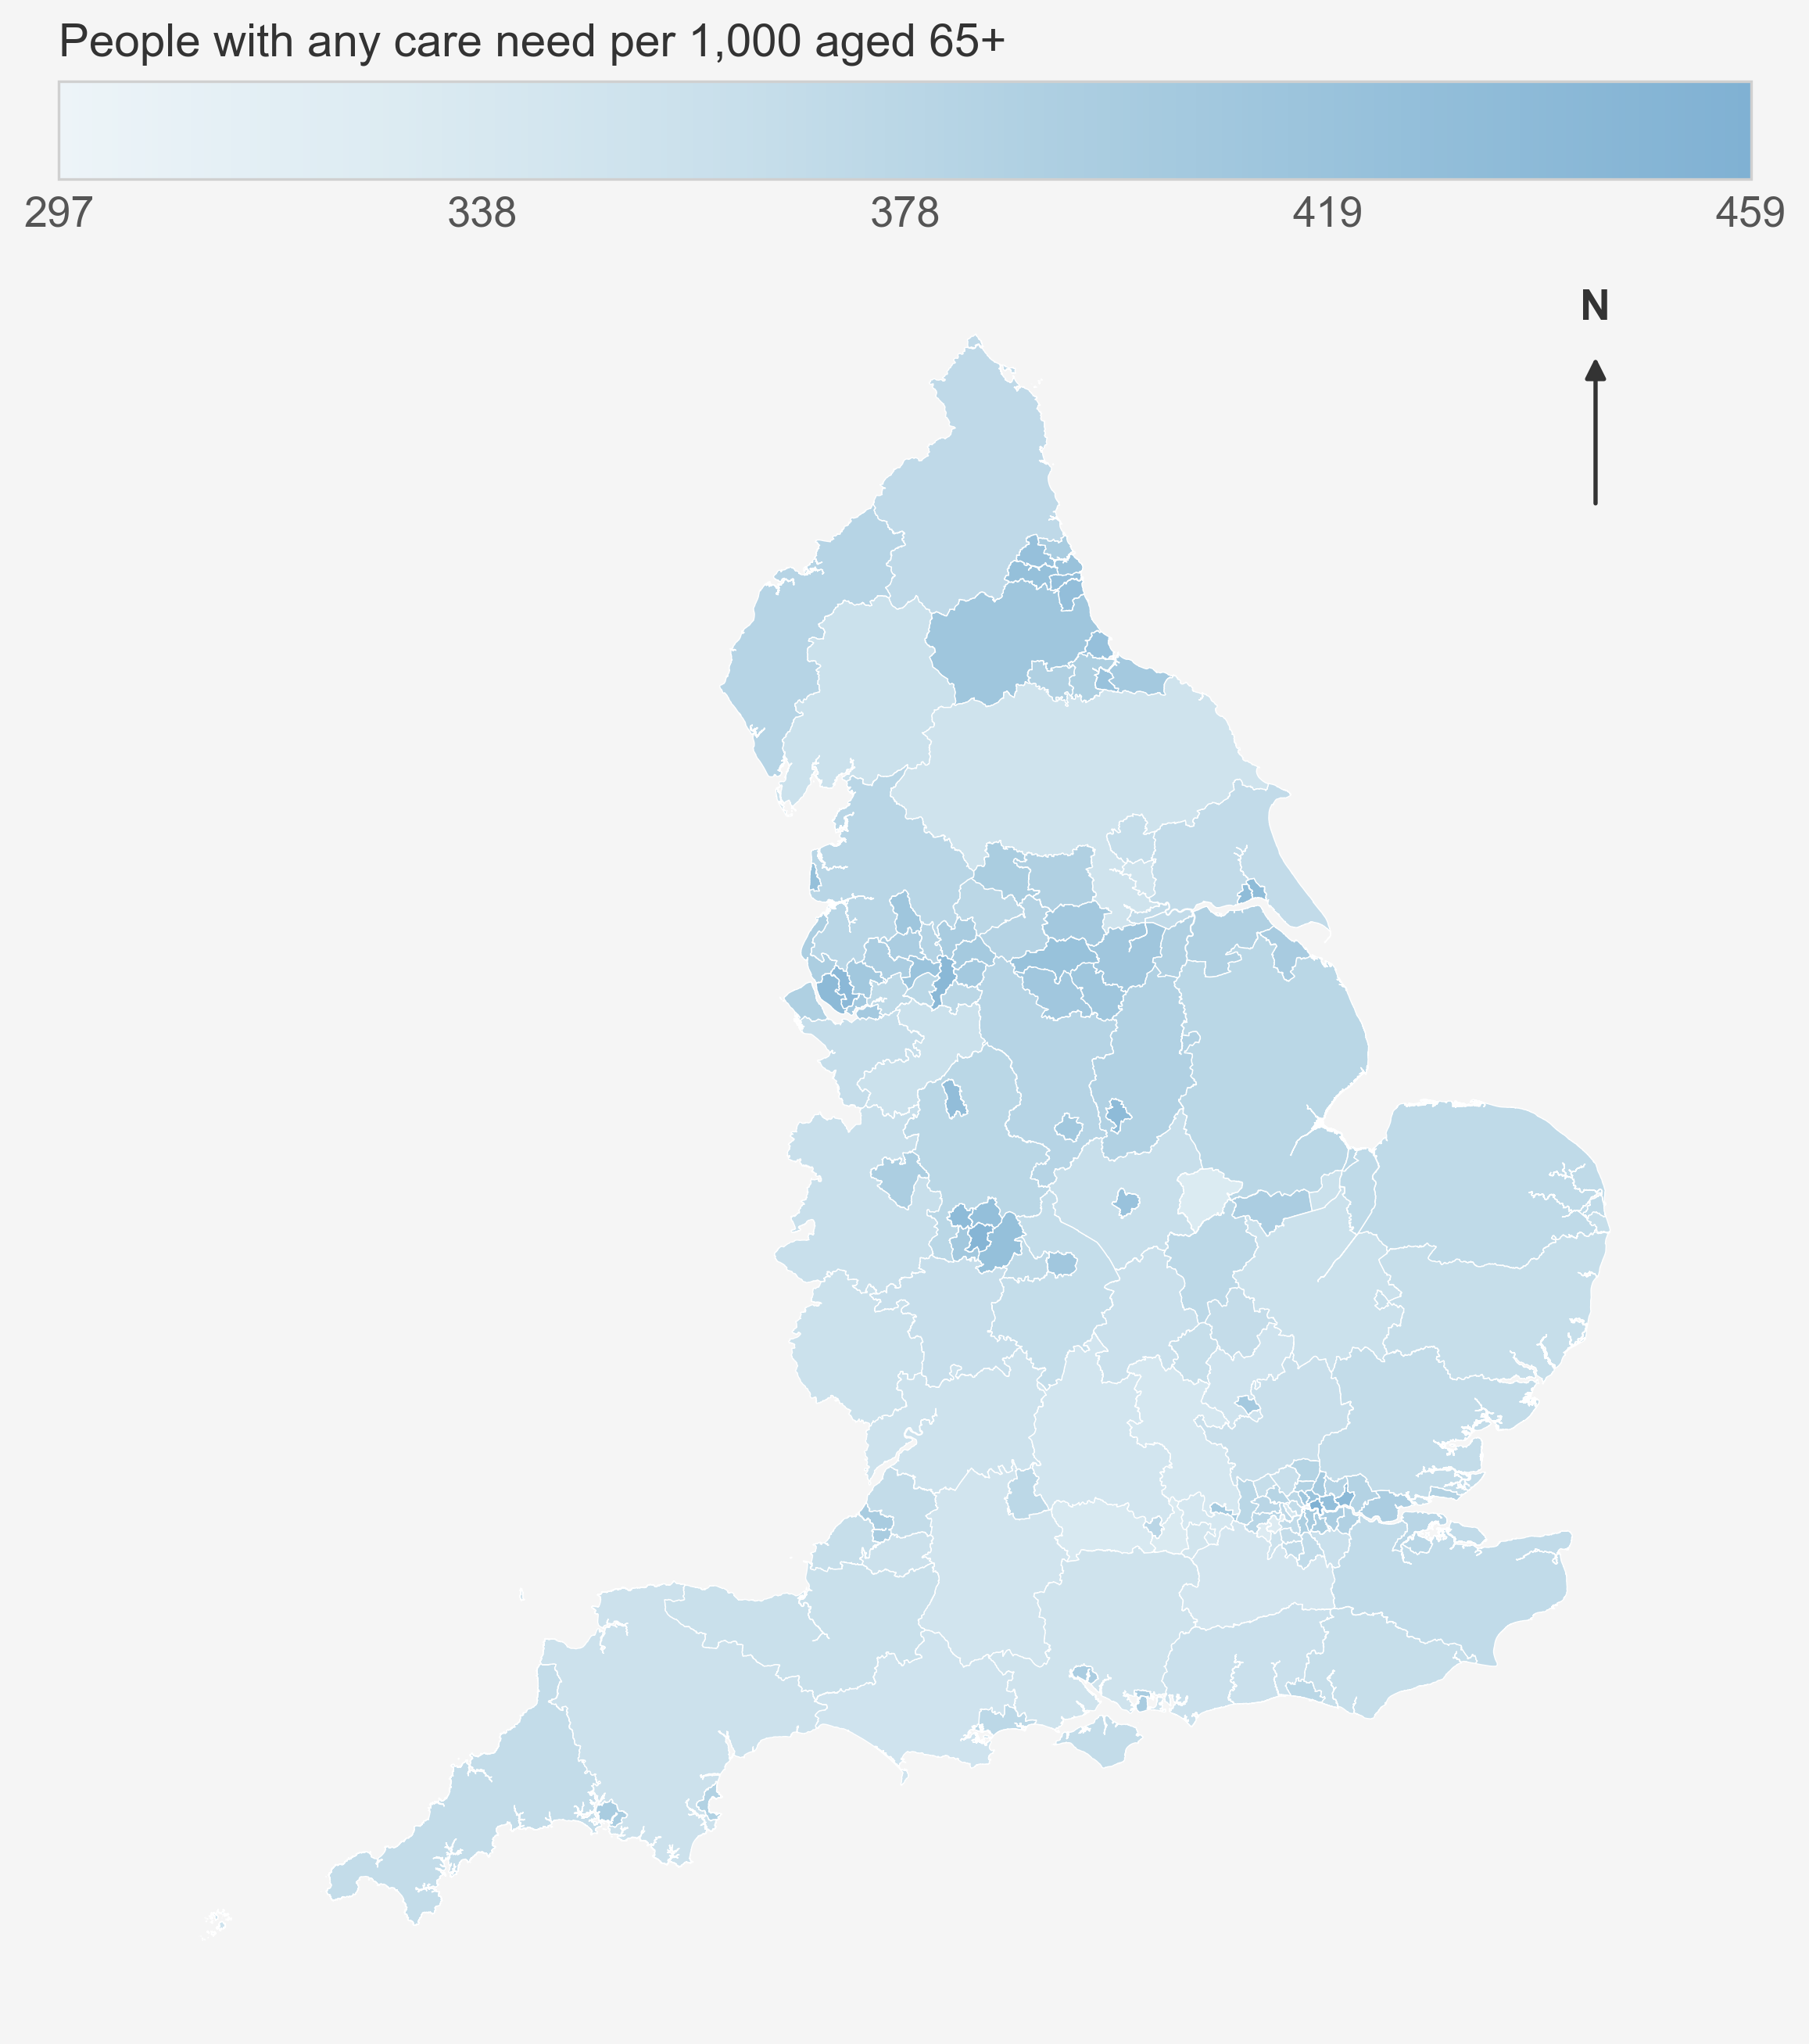

In [6]:
# Create figure

BACKGROUND = "#F5F5F5"
TEXT_PRIMARY = "#333333"
TEXT_SECONDARY = "#555555"
GRID = "#D0D0D0"
BOUNDARY_LINE = "#FFFFFF"
MISSING_FILL = "#D9D9D9"         

DPI = 300

SET3_BLUE = "#80B1D3"
cmap = LinearSegmentedColormap.from_list(
    "set3_blue_prevalence",
    ["#EDF4F8", "#DCEBF2", "#C8DFEB", "#ACCEE1", "#94BFDA", SET3_BLUE],
    N=256,
)
cmap.set_bad(MISSING_FILL)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 14,
    "axes.labelsize": 15,
    "axes.labelcolor": TEXT_PRIMARY,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "text.color": TEXT_PRIMARY,
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "savefig.facecolor": BACKGROUND,
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
    "pdf.fonttype": 42,  
    "ps.fonttype": 42,
})


utla = england_map.loc[
    england_map["CTYUA23CD"].str.startswith("E", na=False),
    ["CTYUA23CD", "CTYUA23NM", "geometry"],
].copy()


utla = utla[utla.geometry.notna() & ~utla.geometry.is_empty]

invalid = ~utla.geometry.is_valid
if invalid.any():
    utla.loc[invalid, "geometry"] = utla.loc[invalid, "geometry"].make_valid()

utla = (
    utla.to_crs(epsg=27700)
    .rename(columns={"CTYUA23CD": "code", "CTYUA23NM": "name"})
    .reset_index(drop=True)
)

gdf = utla.merge(
    df[["area_code", "care_1000_est"]],
    left_on="code",
    right_on="area_code",
    how="left",
    validate="1:1",
).reset_index(drop=True)

gdf["care_1000_est"] = pd.to_numeric(gdf["care_1000_est"], errors="coerce")

values = gdf["care_1000_est"].dropna()
print(f"{len(gdf):,} authorities on the map, {len(values):,} with an estimate")

vmin, vmax = float(values.min()), float(values.max())
norm = Normalize(vmin=vmin, vmax=vmax)


fig = plt.figure(figsize=(7.6, 8.6), dpi=DPI, facecolor=BACKGROUND,
                 layout="constrained")

grid = fig.add_gridspec(2, 1, height_ratios=[0.055, 1.0], hspace=0.015)
cax = fig.add_subplot(grid[0, 0])
ax = fig.add_subplot(grid[1, 0])
for a in (ax, cax):
    a.set_facecolor(BACKGROUND)


gdf[gdf["care_1000_est"].notna()].plot(
    column="care_1000_est",
    cmap=cmap,
    norm=norm,
    ax=ax,
    linewidth=0.35,
    edgecolor=BOUNDARY_LINE,
)
ax.set_axis_off()

ax.annotate(
    "", xy=(0.945, 0.945), xytext=(0.945, 0.855), xycoords="axes fraction",
    arrowprops={"arrowstyle": "-|>", "color": TEXT_PRIMARY,
                "linewidth": 1.3, "mutation_scale": 13},
    zorder=20,
)
ax.text(0.945, 0.958, "N", transform=ax.transAxes, ha="center", va="bottom",
        fontsize=13, fontweight="bold", color=TEXT_PRIMARY, zorder=20)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")

ticks = np.linspace(vmin, vmax, 5)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:,.0f}" for t in ticks])
cbar.ax.tick_params(labelsize=13, length=0, pad=5, colors=TEXT_SECONDARY)
cbar.outline.set_edgecolor(GRID)
cbar.outline.set_linewidth(0.8)

cax.set_title("People with any care need per 1,000 aged 65+",
              fontsize=14, color=TEXT_PRIMARY, loc="left", pad=8)

fig.savefig("../figures/fig_care_need_prevalence_map.pdf",
            bbox_inches="tight", facecolor=fig.get_facecolor())

plt.show()